In [1]:
!pip install opencv-python

### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout

### Load DataSet

In [3]:
dataset_path = r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Food Classification\Food Classification dataset'

### Loading and Splitting the Image Dataset

In [4]:
train_df = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size = 32,
    image_size = (256, 256),
    validation_split = 0.2,
    subset='training',
    seed = 42
)

test_df = keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size = (256, 256),
    validation_split=0.2,
    subset='validation',
    seed=42
)

Found 23873 files belonging to 34 classes.
Using 19099 files for training.
Found 23873 files belonging to 34 classes.
Using 4774 files for validation.


### Normalization

In [5]:
def process(image, label):
    image = tf.cast(image / 255., tf.float32)
    return image, label

train_df = train_df.map(process)
test_df = test_df.map(process)

## CNN Archeticture

In [ ]:
model = Sequential()

model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(3, 3), strides=2, padding='valid'))
model.add(BatchNormalization())
model.add(Dropout(0.1))

# Flatten Layer
model.add(Flatten())

# Fully Connected Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))

# Output Layer
model.add(Dense(34, activation='softmax'))

c:\Users\M Arshad\.conda\envs\deep\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 127, 127, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 127, 127, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 63, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 31, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 15376)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,968,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 34)             │         1,122 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,005,042 (7.65 MB)

 Trainable params: 2,004,818 (7.65 MB)

 Non-trainable params: 224 (896.00 B)

### Model Compilation

In [8]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
history = model.fit(train_df, epochs=10, validation_data=test_df)

Epoch 1/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 3798s 6s/step - accuracy: 0.0920 - loss: 3.4108 - val_accuracy: 0.0469 - val_loss: 3.4479
Epoch 2/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 1901s 3s/step - accuracy: 0.1667 - loss: 2.8038 - val_accuracy: 0.1062 - val_loss: 3.1588
Epoch 3/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 1293s 2s/step - accuracy: 0.2233 - loss: 2.5377 - val_accuracy: 0.1276 - val_loss: 3.2722
Epoch 4/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 1286s 2s/step - accuracy: 0.2602 - loss: 2.3792 - val_accuracy: 0.1114 - val_loss: 4.8018
Epoch 5/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 1655s 3s/step - accuracy: 0.2997 - loss: 2.2457 - val_accuracy: 0.3117 - val_loss: 2.3019
Epoch 6/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 2204s 4s/step - accuracy: 0.3395 - loss: 2.1016 - val_accuracy: 0.2587 - val_loss: 2.5866
Epoch 7/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 1983s 3s/step - accuracy: 0.3897 - loss: 1.9396 - val_accuracy: 0.2321 - val_loss: 3.3946
Epoch 8/10
597/597 ━━━━━━━━━━━━━━━━━━━━ 4099s 7s/step - accuracy: 0.4415 - loss: 1.7603 - 

## Evaluation (Loss & Accuracy Plots)

### Accuracy

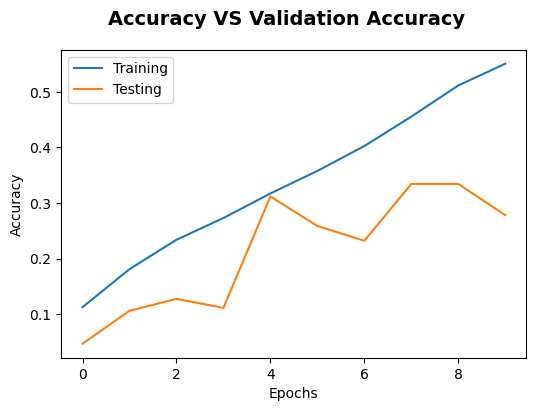

In [18]:
plt.figure(figsize = (6, 4))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Testing')
plt.suptitle("Accuracy VS Validation Accuracy", fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Loss

<function matplotlib.pyplot.show(close=None, block=None)>

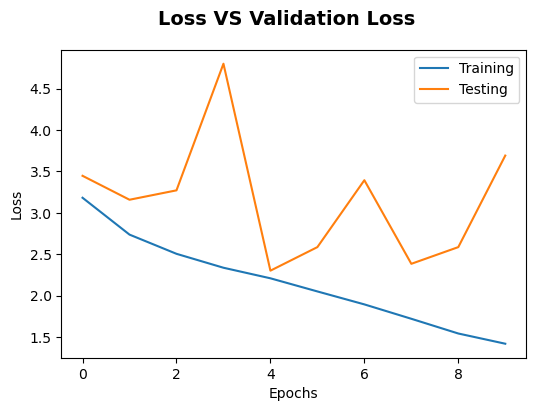

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Testing')
plt.suptitle("Loss VS Validation Loss", fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show

## Model Prediction

In [31]:
# img_path = r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Food Classification\Food Classification dataset\burger\003.jpg'

In [32]:
import cv2
test_img = cv2.imread(r'E:\Deep Learning\DL\1 Deep Learning Projects\CNN\Food Classification\Food Classification dataset\burger\003.jpg')

## Original Image

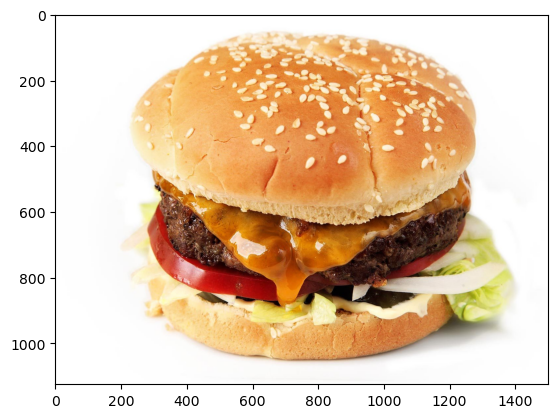

In [33]:
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))

In [34]:
test_img.shape

(1125, 1500, 3)

In [35]:
test_img = cv2.resize(test_img, (256, 256))

In [36]:
test_input = cv2.resize(test_img, (256, 256)).reshape(1, 256, 256, 3)

In [37]:
class_names = [
    'apple_pie',
    'Baked Potato',
    'burger',
    'butter_naan',
    'chai',
    'chapati',
    'cheesecake',
    'chicken_curry',
    'chole_bhature',
    'Crispy Chicken',
    'dal_makhani',
    'dhokla',
    'Donut',
    'fried_rice',
    'Fries',
    'Hot Dog',
    'ice_cream',
    'idli',
    'jalebi',
    'kaathi_rolls',
    'kadai_paneer',
    'kulfi',
    'masala_dosa',
    'momos',
    'omelette',
    'paani_puri',
    'pakode',
    'pav_bhaji',
    'pizza',
    'samosa',
    'Sandwich',
    'sushi',
    'Taco',
    'Taquito'
]

# Model Prediction

In [38]:
prediction = model.predict(test_input)
predicted_class = np.argmax(prediction[0])

print("Predicted Class : ", class_names[predicted_class])
print("Confidence : ", prediction[0][predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
Predicted Class :  burger
Confidence :  1.0
